# Lab 2: Assestment of aircraft engine vanes quality using textural features

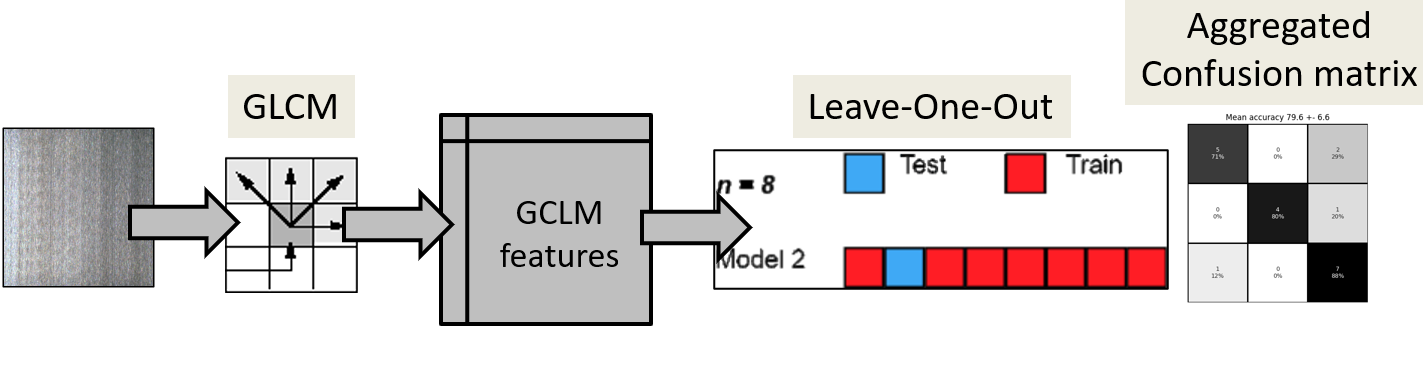

## Import and settings

In [2]:
!pip install scikit-image

   ---------------------------------------- 0.0/11.9 MB ? eta -:--:--
   ------------------------------------ --- 10.7/11.9 MB 61.0 MB/s eta 0:00:01
   ---------------------------------------- 11.9/11.9 MB 53.0 MB/s  0:00:00

   ---------------------------------------- 0/3 [tifffile]
   ------------- -------------------------- 1/3 [imageio]
   ------------- -------------------------- 1/3 [imageio]
   ------------- -------------------------- 1/3 [imageio]
   ------------- -------------------------- 1/3 [imageio]
   ------------- -------------------------- 1/3 [imageio]
   -------------------------- ------------- 2/3 [scikit-image]
   -------------------------- ------------- 2/3 [scikit-image]
   -------------------------- ------------- 2/3 [scikit-image]
   -------------------------- ------------- 2/3 [scikit-image]
   -------------------------- ------------- 2/3 [scikit-image]
   -------------------------- ------------- 2/3 [scikit-image]
   -------------------------- ------------- 2/3

In [3]:
!pip install glob

ERROR: Could not find a version that satisfies the requirement glob (from versions: none)
ERROR: No matching distribution found for glob


In [4]:
import os
import glob
import skimage
import numpy as np
from PIL import Image
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.decomposition import PCA
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import RandomizedSearchCV

In [41]:
!git clone https://github.com/frpnz/teaching-Roughness.git
ROOTDIR_DATASET = "teaching-Roughness/"

fatal: destination path 'teaching-Roughness' already exists and is not an empty directory.


## Functions

In [37]:
def seaborn_cm(cm, ax, tick_labels, fontsize=14, title=None, sum_actual="over_columns",
               xrotation=0, yrotation=0):
    """
    Function to plot a confusion matrix
    """
    from matplotlib import cm as plt_cmap
    group_counts = ["{:0.0f}".format(value) for value in cm.flatten()]
    if sum_actual == "over_columns":
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    elif sum_actual == "over_rows":
        cm = cm.astype('float') / cm.sum(axis=0)[:, np.newaxis]
    else:
        print("sum_actual must be over_columns or over_rows")
        exit()
    cm = np.nan_to_num(cm)
    mean_acc = np.mean(np.diag(cm)[cm.sum(axis=1) != 0])
    std_acc = np.std(np.diag(cm))
    group_percentages = ["{:0.0f}".format(value*100) for value in cm.flatten()]
    cm_labels = [f"{c}\n{p}%" for c, p in zip(group_counts, group_percentages)]
    cm_labels = np.asarray(cm_labels).reshape(len(tick_labels), len(tick_labels))
    sns.heatmap(cm,
                ax=ax,
                annot=cm_labels,
                fmt='',
                cbar=False,
                cmap=plt_cmap.Greys,
                linewidths=1, linecolor='black',
                annot_kws={"fontsize": fontsize},
                xticklabels=tick_labels,
                yticklabels=tick_labels)
    ax.set_yticklabels(ax.get_yticklabels(), size=fontsize, rotation=yrotation)
    ax.set_xticklabels(ax.get_xticklabels(), size=fontsize, rotation=xrotation)
    if title:
        title = f"{title}\nMean accuracy {mean_acc * 100:.1f} +- {std_acc * 100:.1f}"
    else:
        title = f"Mean accuracy {mean_acc * 100:.1f} +- {std_acc * 100:.1f}"
    ax.set_title(title)
    if sum_actual == "over_columns":
        ax.set_ylabel("Actual")
        ax.set_xlabel("Predicted")
    else:
        ax.set_ylabel("Predicted")
        ax.set_xlabel("Actual")

def my_imshow(image, title=None):
    fig, ax = plt.subplots(1, 1)
    if len(image.shape) > 2:
        ax.imshow(image)
    else:
        ax.imshow(image, cmap=plt.cm.gray)
    ax.axis("off")
    if title:
        ax.set_title(title)

#Assignment #1: Get all filepaths ending with `".bmp"`

In [43]:
filepaths = list()
for class_name in os.listdir(ROOTDIR_DATASET):
    for filepath in glob.glob(os.path.join(ROOTDIR_DATASET, class_name, "*.bmp")):
        filepaths.append(filepath)
filepaths = np.array(filepaths)
print(f"Found {len(filepaths)} files in {ROOTDIR_DATASET}")

Found 20 files in teaching-Roughness/


#Assignment #2: Plot some images from training set.

Create a single figure object with several subplots and remove axis where not needed.
Set the filename as title for the single subplot.

There exixt several packages to manipulate images in Python. Consider the following three, that are very popular:


*   [skimage](https://scikit-image.org/)
*   [Image module](https://pillow.readthedocs.io/en/stable/reference/Image.html) of Pillow
*   [OpenCV](https://pypi.org/project/opencv-python/)


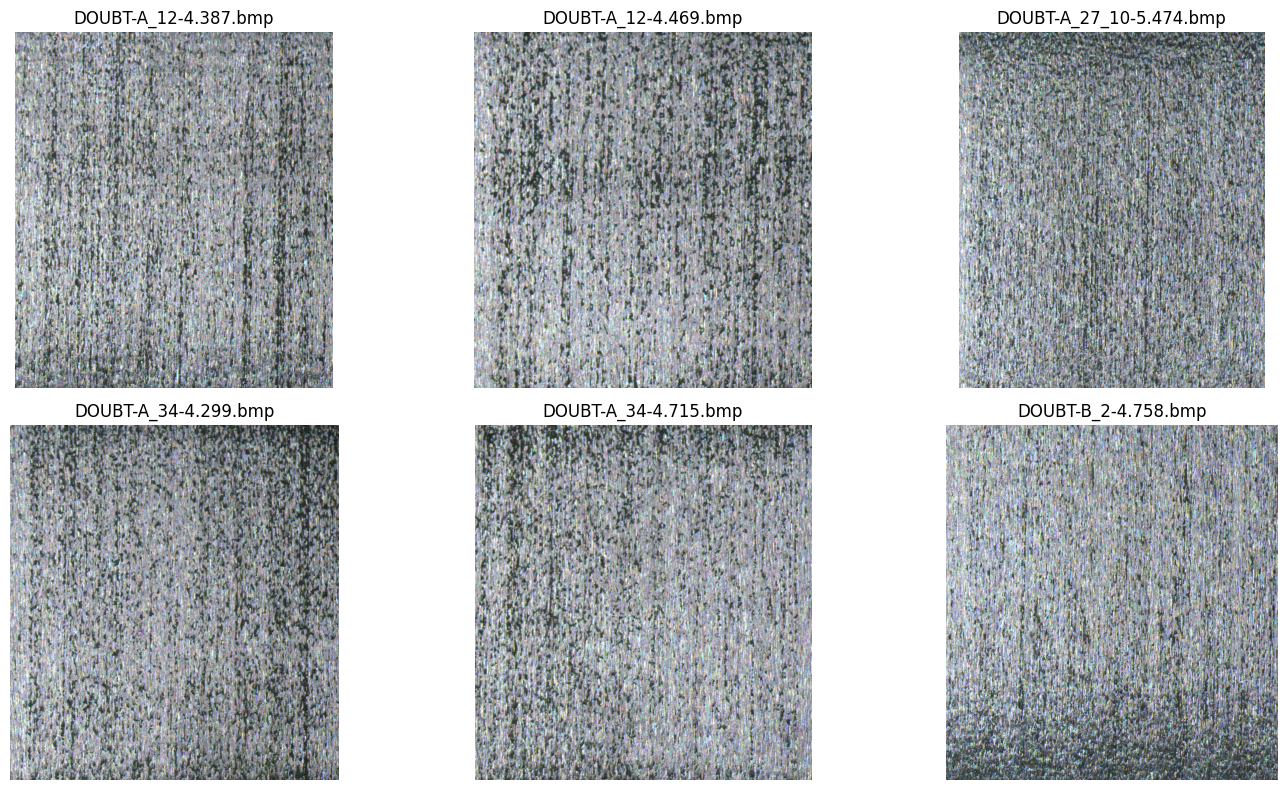

In [56]:

IMG_DIR = '../notebooks/teaching-Roughness/data'  
image_paths = glob.glob(os.path.join(IMG_DIR, '**', '*.bmp'), recursive=True)
sample_images = image_paths[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, img_path in enumerate(sample_images):
    try:
        img = skio.imread(img_path)
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(os.path.basename(img_path))
        axes[i].axis('off')
    except Exception as e:
        axes[i].set_title(f'Error: {os.path.basename(img_path)}')
        axes[i].axis('off')

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


# Assignment #3: extract the so-called Gray-Level Co-Occurrence matrix (GLCM)

The GLCM is computed by calculating how often a pixel with the intensity (gray-level) value i occurs in a specific spatial relationship to a pixel with the value j.

To illustrate, the following figure shows how graycomatrix calculates the first three values in a GLCM. In the output GLCM, element (1, 1) contains the value 1 because there is only one instance in the input image where two horizontally adjacent pixels have the values 1 and 1, respectively. Element (1, 2) contains the value 2 because there are two instances where two horizontally adjacent pixels have the values 1 and 2. Element (1, 3) has the value 0 because there are no instances of two horizontally adjacent pixels with the values 1 and 3. graycomatrix continues processing the input image, scanning the image for other pixel pairs (i, j) and recording the sums in the corresponding elements of the GLCM.

source: https://it.mathworks.com/help/images/create-a-gray-level-co-occurrence-matrix.html

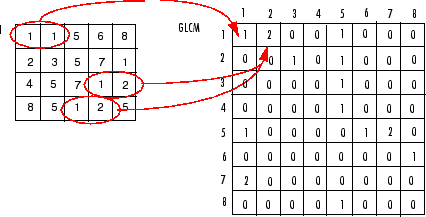

# Code the pipeline to extract the GLC from a single image.


Steps:

1. Some preprocssing operations are required. See the documentation of [skimage.feature.graycomatrix](https://scikit-image.org/docs/stable/api/skimage.feature.html#graycomatrix), paying particular **attention to the required input format**.
1. Exploit the function [skimage.feature.graycomatrix](https://scikit-image.org/docs/stable/api/skimage.feature.html#graycomatrix) to compute the GLCM. For now, set a single value for the `distances` and `angles` parameters.
2. Compute all the available texture properties of the GLCM, through [graycoprops](https://scikit-image.org/docs/stable/api/skimage.feature.html#graycoprops) function.
4. Go back to step 2 and try different values for the `distances` and `angles` parameters. How this affect the shape of the value returned by the *skimage.feature.graycomatrix* function?

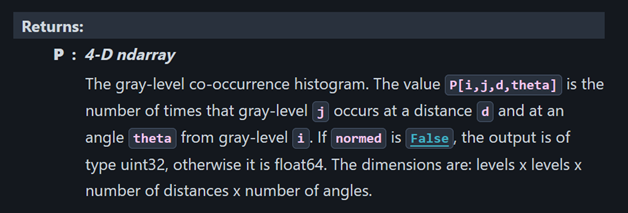

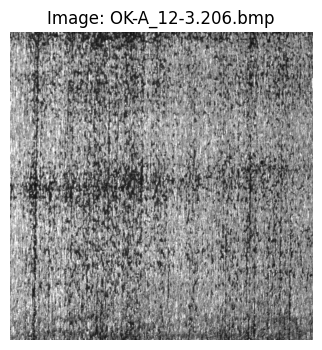

contrast (distances x angles):
[[ 387.0728346   512.1322677   136.23186958  467.05303264]
 [1131.430079    512.1322677   410.66703064  467.05303264]
 [2271.76661204 2019.10820045  985.28327271 1962.17044818]
 [2994.38216928 2892.84229162 1805.31909656 2906.0795793 ]]

dissimilarity (distances x angles):
[[14.94195498 17.25306245  8.39274199 16.56901539]
 [26.34428171 17.25306245 14.8991146  16.56901539]
 [37.6639431  35.37762534 23.38469712 34.92488736]
 [43.41100408 42.69323041 32.4598238  42.81065169]]

homogeneity (distances x angles):
[[0.07315444 0.06272448 0.13400138 0.06490532]
 [0.03991582 0.06272448 0.07758399 0.06490532]
 [0.02802452 0.02985773 0.04991816 0.02999639]
 [0.02395075 0.02435485 0.03525056 0.02417383]]

ASM (distances x angles):
[[1.06379188e-04 9.23861164e-05 1.90551349e-04 9.57092131e-05]
 [6.27134204e-05 9.23861164e-05 1.08136988e-04 9.57092131e-05]
 [4.80837567e-05 5.01166363e-05 7.15906841e-05 5.05679002e-05]
 [4.46500915e-05 4.50708513e-05 5.43639427e-05 4.5

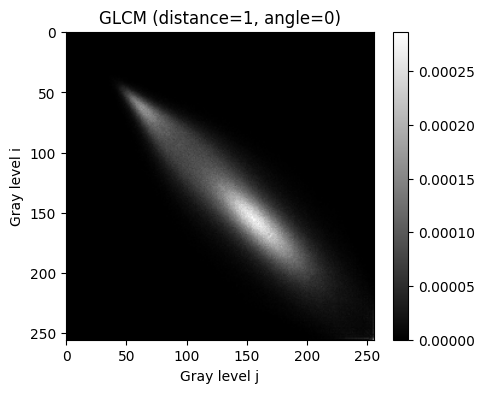

In [64]:
from skimage import io, color
from skimage.feature import graycomatrix, graycoprops


data_dir = os.path.join('teaching-Roughness', 'data')
img_name = 'OK-A_12-3.206.bmp' 
img_path = os.path.join(data_dir, img_name)

img = io.imread(img_path)

if img.ndim == 3:
        img_gray = color.rgb2gray(img)
        img_gray = (img_gray * 255).astype(np.uint8)
else:
    img_gray = img
    
plt.figure(figsize=(4, 4))
plt.imshow(img_gray, cmap='gray')
plt.title(f'Image: {img_name}')
plt.axis('off')
plt.show()

distances = [1, 2, 4, 8]
angles = [0, np.pi/4, np.pi/2, 3*np.pi/4]

glcms = graycomatrix(img_gray, 
                     distances=distances, 
                     angles=angles, 
                     levels=256, 
                     symmetric=True, 
                     normed=True)

props = ['contrast', 'dissimilarity', 'homogeneity', 'ASM', 'energy', 'correlation']
results = {}
for prop in props:
    results[prop] = graycoprops(glcms, prop)

for prop in props:
    print(f"{prop} (distances x angles):\n{results[prop]}\n")

plt.figure(figsize=(5, 4))
plt.imshow(glcms[:, :, 0, 0], cmap='gray')
plt.title('GLCM (distance=1, angle=0)')
plt.xlabel('Gray level j')
plt.ylabel('Gray level i')
plt.colorbar()
plt.show()

The shape of the GLCM returned by graycomatrix is (levels, levels, number of distances, number of angles), so increasing distances or angles adds more slices to the third and fourth dimensions of the array

#Assignment #4: Create the dataset (X, y) by:

1.   Extracting the GLCM from all images.
2.   Extracting the main properties from the GLCM matrix, six features in total (see [graycoprops](https://scikit-image.org/docs/stable/api/skimage.feature.html#graycoprops)). Employ different values for the  `distances` and `angles` parameters of [skimage.feature.graycomatrix](https://scikit-image.org/docs/stable/api/skimage.feature.html#graycomatrix).
3.   Extract the corresponding numerical label from the filename.




In [65]:
from skimage import io, color
from skimage.feature import graycomatrix, graycoprops

img_dir = os.path.join('teaching-Roughness', 'data')
img_files = [f for f in os.listdir(img_dir) if f.lower().endswith('.bmp')]
label_mapping = {"OK": 0, "NOK": 1, "DOUBT": 2}
props = ['contrast', 'dissimilarity', 'homogeneity', 'ASM', 'energy', 'correlation']
distances = [1, 2, 4, 8]
angles = [0, np.pi/4, np.pi/2, 3*np.pi/4]

X_glcm = []
X_glcm_props = []
y = []

for fname in img_files:
    img_path = os.path.join(img_dir, fname)
    img = io.imread(img_path)
    if img.ndim == 3:
        img_gray = color.rgb2gray(img)
        img_gray = (img_gray * 255).astype(np.uint8)
    else:
        img_gray = img
    glcm = graycomatrix(img_gray, distances=distances, angles=angles, levels=256, symmetric=True, normed=True)
    X_glcm.append(glcm)
    features = []
    for prop in props:
        prop_matrix = graycoprops(glcm, prop)
        features.append(prop_matrix.mean())
    X_glcm_props.append(features)
    label_str = fname.split('-')[0]
    y.append(label_mapping[label_str])

X_glcm = np.array(X_glcm)
X_glcm_props = np.array(X_glcm_props)
y = np.array(y)

print("X_glcm_props shape:", X_glcm_props.shape)
print("y shape:", y.shape)
print("First 5 feature vectors:\n", X_glcm_props[:5])
print("First 5 labels:", y[:5])

X_glcm_props shape: (20, 6)
y shape: (20,)
First 5 feature vectors:
 [[1.37575708e+03 2.65695416e+01 5.16083988e-02 8.30618171e-05
  8.92072884e-03 6.10693028e-01]
 [1.20702729e+03 2.45224200e+01 5.70022235e-02 9.21913270e-05
  9.37156517e-03 6.78950524e-01]
 [1.61239775e+03 2.93972796e+01 4.48860777e-02 6.64502428e-05
  7.99484955e-03 5.72401523e-01]
 [1.25549762e+03 2.53790139e+01 5.37952006e-02 8.26689780e-05
  8.88705482e-03 6.70500910e-01]
 [1.34199049e+03 2.63409899e+01 5.10946347e-02 8.76111008e-05
  9.17665888e-03 6.12782501e-01]]
First 5 labels: [2 2 2 2 2]


##Assignment #4.1: Reshape the dataset to be fed to sklearn, i.e. a `n_samples by m_features` matrix.
Note that the number of features depends on distances and angles parameters of skimage.feature.graycomatrix

In [66]:
X_glcm_props = X_glcm_props.reshape(X_glcm_props.shape[0], -1)

#Assignment #5: Build and optimize the ML pipeline in a Leave-One-Out (LOO) cross-validation fashion and evaluate leveragin a confusion matrix
1.   Scale the data
2.   Implement PCA
3.   Optimize the hyperparameters of a classifier (e.g., SVM) and train it

> Note that in this case study we have really few samples. For this reason, we opted to built a LOO setting in which we use multiple training set, while at each iteration one single sample is consdiered as the test set. In this way, **we are evaluating a learning method**, not just an individual learned model.





In [ ]:
from sklearn.model_selection import LeaveOneOut, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix

loo = LeaveOneOut()
cm_aggregated = np.zeros((3, 3), dtype=int)
y_true = []
y_pred = []

for train_index, test_index in loo.split(X_glcm_props):
    X_train, X_test = X_glcm_props[train_index], X_glcm_props[test_index]
    y_train, y_test = y[train_index], y[test_index]
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    pca = PCA(n_components=0.95, svd_solver='full')
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    param_grid = {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto'], 'kernel': ['rbf', 'linear']}
    clf = GridSearchCV(SVC(), param_grid, cv=3)
    clf.fit(X_train_pca, y_train)
    y_pred_test = clf.predict(X_test_pca)
    cm_aggregated += confusion_matrix(y_test, y_pred_test, labels=[0, 1, 2])
    y_true.append(y_test[0])
    y_pred.append(y_pred_test[0])

print("Aggregated confusion matrix:\n", cm_aggregated)


Aggregated confusion matrix:
 [[3 0 4]
 [1 1 3]
 [2 1 5]]


## Confusion matrix

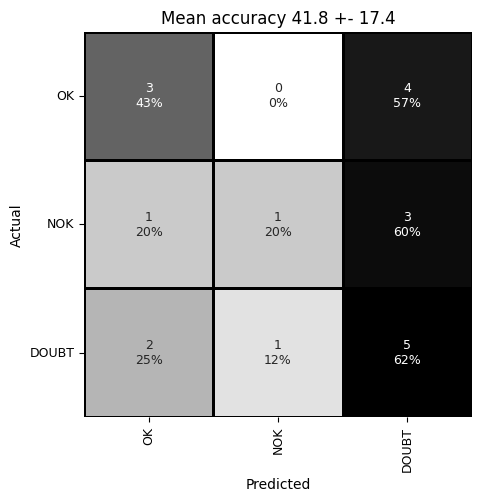

In [69]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
seaborn_cm(cm_aggregated, ax, list(label_mapping.keys()), fontsize=9, xrotation=90)